# Dose-Response Curve: locating the actual steering threshold

## The overclaim this fixes

This project currently tests steering at exactly **two** doses, 1x and 2x, and describes the
result as a cliff -- `notes/context-and-decisions.md` says the effect is "not smooth,
proportional degradation -- it's closer to a cliff: no measurable effect at reference strength,
then severe collapse at 2x."

Two points cannot support that. A cliff, a smooth ramp, and a gentle sigmoid all pass through
"nothing at 1x, severe at 2x". The shape is currently asserted, not measured, and a reviewer who
notices will be right to object.

## What this produces instead

Eight doses spanning 0 to 2x on ProtGPT2 at layer 12, N=50 each, everything else held at the
project's standard configuration. From those points:

1. **The measured shape** -- is it actually a cliff, or is it gradual?
2. **A fitted threshold with a confidence interval** -- the dose at which collapse begins in
   earnest. This is the number the paper can hand to a practitioner: *stay below this.*
3. **The largest statistically safe dose** -- the highest multiplier whose collapse rate is
   still indistinguishable from CONTROL. Arguably the more useful of the two numbers, because it
   is a direct empirical statement rather than a model-derived one.

Together these turn the steering arm from "steering breaks things" (true but unsurprising) into
"here is the measured safe operating envelope for activation steering on this model" -- which is
a constructive, quotable contribution, and a much better fit for a track about moving from
benchmarks toward real closed-loop use.

## A modelling detail that matters

Collapse does not start at zero. ProtGPT2's natural collapse rate is ~53-62%, so a conventional
"dose at which 50% of samples fail" is meaningless here -- the model is already past 50% before
any steering is applied. This notebook therefore fits a **floored** logistic:

    p(alpha) = p0 + (1 - p0) * sigmoid(k * (alpha - alpha_50))

where `p0` is the CONTROL collapse rate and `alpha_50` is the dose that consumes half the
*available headroom* between the natural failure rate and total collapse. That is the correct
analogue of an EC50 for an outcome with a high baseline, and reporting a naive LD50 instead
would be a real error given how high `p0` is.

Fitting is by maximum likelihood on the binomial counts, with a bootstrap CI on `alpha_50`.

## Vector choice

Uses the naive `v_L` rebuilt from `03-ai4dd-uccs-baseline-test.ipynb`'s exact contrastive sets
-- the same construction as `35-ai4dd-random-direction-control.ipynb`. Two reasons: it needs no
candidate-pool fold (saving ~200 folds, which is what makes eight doses affordable), and its
natural norm *is* `REFERENCE_NORM`, so the 1x and 2x points here should reproduce locked §1a
(CONTROL 62.0% -> 1x 60.0% -> 2x 100.0%) and serve as an internal calibration check.

Results are also reported in `alpha_rel` units (see `34-ai4dd-residual-norm-audit.ipynb`), so
the threshold transfers to other models rather than being a ProtGPT2-specific magic number.

Kaggle setup: Accelerator = **GPU T4 x1 or x2**, Internet = **ON**. Expect ~90-120 minutes
(8 conditions x 50 folds).


In [2]:
import warnings
warnings.filterwarnings("ignore")

import gc
import math
import collections
import urllib.request

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, EsmForProteinFolding

torch.manual_seed(2024)
np.random.seed(2024)

device = "cuda" if torch.cuda.is_available() else "cpu"

REFERENCE_NORM = 583.998
TARGET_LAYER = 12
N_PER_CONDITION = 50
DOSES = [0.0, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def calculate_entropy(seq_str):
    if not seq_str:
        return 0.0
    counts = collections.Counter(seq_str)
    total = len(seq_str)
    return -sum((c / total) * math.log2(c / total) for c in counts.values())

print("Setup complete. CUDA available:", torch.cuda.is_available())
print(f"Doses to test: {DOSES}  ({len(DOSES)} conditions x {N_PER_CONDITION} = "
      f"{len(DOSES) * N_PER_CONDITION} folds)")


Setup complete. CUDA available: True
Doses to test: [0.0, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]  (8 conditions x 50 = 400 folds)


In [3]:
# --- Same naive v_L as 03 and 35. Its natural norm is REFERENCE_NORM, so dose 1.0 here is
#     literally locked §1a's FULL_UCCS_1x condition. ---

positive_seqs = [
    "NLYIQWLKDGGPSSGRPPPS", "LSDEDFKAVFGMTRSAFANLPLWKQQHLKKEKGLF", "GSQIGAKNTGQVQLNLLAL",
    "MQYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTE",
    "MKTIIALSYIFCLVFADYKDDDDKLEHTHHHEASGGNLQVQLQESGGGLVQAGGSLRLSCAASGRTFSNYAMGWFRQAPGKEREFVAAISWSGGSTYYTDSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAASRFRYWGQGTQVTVSS",
    "DEPPQSPWDRVKDFATVYVDAVKPTGKGKV",
]
degenerate_seqs = [
    "AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA", "LGLGLGLGLGLGLGLGLGLGLGLGLGLGLGLGLGL",
    "GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG", "SSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSS",
    "PGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGPGP", "QWQWQWQWQWQWQWQWQWQWQWQWQWQWQWQWQWQ",
]

print(f"Loading ProtGPT2 on {device}...")
tokenizer = AutoTokenizer.from_pretrained("nferruz/ProtGPT2")
plm_model = AutoModelForCausalLM.from_pretrained("nferruz/ProtGPT2").to(device)
plm_model.eval()

def get_mean_activation(model, tokenizer, seq_list, layer):
    acts = []
    for seq in seq_list:
        inputs = tokenizer(seq, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True)
            acts.append(out.hidden_states[layer].mean(dim=1).squeeze(0).cpu())
    return torch.stack(acts)

pos_acts = get_mean_activation(plm_model, tokenizer, positive_seqs, TARGET_LAYER)
neg_acts = get_mean_activation(plm_model, tokenizer, degenerate_seqs, TARGET_LAYER)
v_L_raw = pos_acts.mean(dim=0) - neg_acts.mean(dim=0)
raw_norm = v_L_raw.norm().item()
v_L = (v_L_raw * (REFERENCE_NORM / raw_norm)).to(device)
print(f"Naive v_L raw norm: {raw_norm:.4f} -> normalized to {v_L.norm().item():.4f}")

def measure_resid_norm(model, tokenizer, seqs, layer):
    captured = {}
    def hook(module, inp, out):
        h = out[0] if isinstance(out, (tuple, list)) else out
        captured["h"] = h.detach()
    handle = model.transformer.h[layer].register_forward_hook(hook)
    vals = []
    try:
        for seq in seqs:
            inputs = tokenizer(seq, return_tensors="pt", truncation=True, max_length=256).to(device)
            captured.clear()
            with torch.no_grad():
                model(**inputs)
            if "h" in captured:
                vals.append(captured["h"].float().norm(dim=-1).mean().item())
    finally:
        handle.remove()
    return float(np.mean(vals)) if vals else float("nan")

resid_norm = measure_resid_norm(plm_model, tokenizer, positive_seqs + degenerate_seqs, TARGET_LAYER)
alpha_rel_per_dose = REFERENCE_NORM / resid_norm
print(f"Mean residual-stream norm ‖h‖ at layer {TARGET_LAYER}: {resid_norm:.2f}")
print(f"  => each 1.0 of dose = alpha_rel {alpha_rel_per_dose:.4f} "
      f"(hidden state displaced by ~{alpha_rel_per_dose:.1%} of its own magnitude)")


Loading ProtGPT2 on cuda...


config.json:   0%|          | 0.00/850 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/437 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: nferruz/ProtGPT2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...35}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...35}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Naive v_L raw norm: 583.9979 -> normalized to 583.9980
Mean residual-stream norm ‖h‖ at layer 12: 3397.13
  => each 1.0 of dose = alpha_rel 0.1719 (hidden state displaced by ~17.2% of its own magnitude)


In [4]:
# --- Generate every dose. Disjoint prefix slices and distinct seeds per condition, matching
#     the convention in 24/26/27/28/32/35. ---

UNIPROT_ACCESSIONS = [
    "P0CG48", "P00720", "P02144", "P42212", "P01308", "P61823",
    "P00648", "P99999", "P69905", "P68871", "P00698", "P00441",
]

def fetch_uniprot_sequence(accession, timeout=10):
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.fasta"
    try:
        with urllib.request.urlopen(url, timeout=timeout) as resp:
            text = resp.read().decode("utf-8")
        lines = [l for l in text.strip().split("\n") if l]
        seq = "".join(lines[1:])
        return seq if len(seq) >= 20 else None
    except Exception as e:
        print(f"  skip {accession}: {e}")
        return None

print("Fetching real reference protein sequences from UniProt...")
reference_seqs = []
for acc in UNIPROT_ACCESSIONS:
    seq = fetch_uniprot_sequence(acc)
    if seq:
        reference_seqs.append((acc, seq))
        print(f"  fetched {acc}: {len(seq)} residues")

USED_FALLBACK = False
if not reference_seqs:
    USED_FALLBACK = True
    print()
    print("!" * 78)
    print("!! UniProt fetch returned NOTHING.")
    print("!!")
    print("!! A 'name resolution' error here means Kaggle's Internet toggle is OFF.")
    print("!! Fix: Notebook sidebar -> Session options -> Internet -> ON, then re-run.")
    print("!!")
    print("!! With Internet off the HuggingFace downloads will also fail unless cached.")
    print("!! Turning Internet on is the real fix. This fallback only prevents a crash.")
    print("!!")
    print("!! Falling back to the real protein fragments already hardcoded above")
    print("!! (03-ai4dd-uccs-baseline-test.ipynb's positive_seqs -- real, not synthetic).")
    print("!! WARNING specific to this notebook: the dose ladder needs 400 prefixes across 8")
    print("!! conditions. Drawing them from 6 source proteins instead of 12 materially")
    print("!! reduces prompt diversity, and the fitted threshold is the headline number here.")
    print("!! Strongly prefer re-running with Internet ON rather than trusting a fallback fit.")
    print("!" * 78)
    reference_seqs = [(f"local{i + 1}", s) for i, s in enumerate(positive_seqs)]

def build_prefix_pool(reference_seqs, n_prefixes, min_len=10, max_len=15, seed=11):
    if not reference_seqs:
        raise RuntimeError(
            "No reference sequences available -- neither the UniProt fetch nor the fallback "
            "produced anything. Check Kaggle's Internet setting before re-running."
        )
    rng = np.random.RandomState(seed)
    prefixes = []
    for i in range(n_prefixes):
        acc, seq = reference_seqs[i % len(reference_seqs)]
        plen = rng.randint(min_len, max_len + 1)
        start = rng.randint(0, max(1, len(seq) - plen))
        prefixes.append(seq[start:start + plen])
    return prefixes

def generate_with_vector_steering(model, tokenizer, target_layer, steering_vector, prompts,
                                  max_len=50, seed=0):
    torch.manual_seed(seed)
    model.eval()
    v = None if steering_vector is None else steering_vector.to(device)

    def hook(module, inp, out):
        if v is None:
            return out
        return (out[0] + v,)

    records = []
    for prompt in prompts:
        handle = model.transformer.h[target_layer].register_forward_hook(hook)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            output_ids = model.generate(
                **inputs, max_length=max_len, do_sample=True,
                temperature=1.2, pad_token_id=tokenizer.eos_token_id
            )
        handle.remove()
        seq = tokenizer.decode(output_ids[0], skip_special_tokens=True).replace(" ", "")
        gen_part = seq[len(prompt):] if seq.startswith(prompt) else seq
        records.append({"prompt": prompt, "sequence": seq, "gen_only": gen_part,
                        "entropy": calculate_entropy(gen_part)})
    clear_gpu()
    return records

steer_prefixes = build_prefix_pool(reference_seqs, n_prefixes=len(DOSES) * N_PER_CONDITION + 50,
                                   seed=23)

conditions = {}
for i, dose in enumerate(DOSES):
    name = f"DOSE_{dose:g}x"
    lo, hi = i * N_PER_CONDITION, (i + 1) * N_PER_CONDITION
    vec = None if dose == 0.0 else v_L * dose
    print(f"=== {name} (prefixes {lo}:{hi}, seed {1000 + i}) ===")
    conditions[name] = generate_with_vector_steering(
        plm_model, tokenizer, TARGET_LAYER, vec, steer_prefixes[lo:hi], seed=1000 + i)

print("\n=== Freeing ProtGPT2 from GPU ===")
del plm_model
clear_gpu()


Fetching real reference protein sequences from UniProt...
  fetched P0CG48: 685 residues
  fetched P00720: 164 residues
  fetched P02144: 154 residues
  fetched P42212: 238 residues
  fetched P01308: 110 residues
  fetched P61823: 150 residues
  fetched P00648: 157 residues
  fetched P99999: 105 residues
  fetched P69905: 142 residues
  fetched P68871: 147 residues
  fetched P00698: 147 residues
  fetched P00441: 154 residues
=== DOSE_0x (prefixes 0:50, seed 1000) ===
=== DOSE_0.5x (prefixes 50:100, seed 1001) ===
=== DOSE_0.75x (prefixes 100:150, seed 1002) ===
=== DOSE_1x (prefixes 150:200, seed 1003) ===
=== DOSE_1.25x (prefixes 200:250, seed 1004) ===
=== DOSE_1.5x (prefixes 250:300, seed 1005) ===
=== DOSE_1.75x (prefixes 300:350, seed 1006) ===
=== DOSE_2x (prefixes 350:400, seed 1007) ===

=== Freeing ProtGPT2 from GPU ===


In [5]:
# --- Fold. Same VALID_AA filter and pLDDT<60 threshold as the rest of the project. ---
VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")

class StructuralEvaluatorPTM:
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print("Loading ESMFold...")
        self.tokenizer = AutoTokenizer.from_pretrained("facebook/esmfold_v1")
        self.model = EsmForProteinFolding.from_pretrained("facebook/esmfold_v1", low_cpu_mem_usage=True)
        self.model = self.model.to(self.device).eval()

    def fold_one(self, seq):
        cleaned = "".join(a for a in seq if a in VALID_AA)
        if len(cleaned) < 10:
            return 0.0, 0.0
        inputs = self.tokenizer([cleaned], return_tensors="pt", add_special_tokens=False).to(self.device)
        plddt, ptm = 0.0, 0.0
        try:
            with torch.no_grad():
                out = self.model(**inputs)
            raw_plddt = float(np.mean(out.plddt.cpu().numpy()))
            plddt = raw_plddt * 100.0 if raw_plddt <= 1.5 else raw_plddt
            ptm = float(out.ptm.item()) if hasattr(out, "ptm") else 0.0
        except RuntimeError:
            clear_gpu()
        return plddt, ptm

evaluator = StructuralEvaluatorPTM()
for name in conditions:
    print(f"Folding {name}...")
    for r in conditions[name]:
        plddt, ptm = evaluator.fold_one(r["sequence"])
        r["plddt"] = plddt
        r["ptm"] = ptm
        r["collapse"] = int(0.0 < plddt < 60.0)
del evaluator
clear_gpu()

def wilson_ci(k, n, z=1.959963985):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    d = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / d
    return (max(0.0, centre - half), min(1.0, centre + half))

rows = []
for dose, name in zip(DOSES, conditions):
    recs = conditions[name]
    k = int(np.sum([r["collapse"] for r in recs]))
    n = len(recs)
    lo, hi = wilson_ci(k, n)
    rows.append({
        "dose": dose, "condition": name, "collapsed": k, "n": n, "rate": k / n,
        "ci_lo": lo, "ci_hi": hi, "alpha_rel": dose * alpha_rel_per_dose,
        "entropy": float(np.mean([r["entropy"] for r in recs])),
        "plddt": float(np.mean([r["plddt"] for r in recs if r["plddt"] > 0])),
        "ptm": float(np.mean([r["ptm"] for r in recs if r["plddt"] > 0])),
    })
dose_df = pd.DataFrame(rows)

print(f"\n{'Dose':>7s} {'alpha_rel':>10s} {'collapsed':>11s} {'rate':>8s} {'95% CI':>20s} "
      f"{'Entropy':>9s} {'pLDDT':>8s}")
print("-" * 82)
for _, r in dose_df.iterrows():
    ci_str = "[{:.1%}, {:.1%}]".format(r["ci_lo"], r["ci_hi"])
    print(f"{r['dose']:6.2f}x {r['alpha_rel']:10.4f} {int(r['collapsed']):5d}/{int(r['n']):<5d} "
          f"{r['rate']:7.1%} {ci_str:>20s} {r['entropy']:9.3f} {r['plddt']:8.2f}")

print()
print("Calibration against locked §1a (same vector, layer, norm):")
print("  §1a:      CONTROL 62.0%  ->  1x 60.0%  ->  2x 100.0%")
r0 = dose_df[dose_df["dose"] == 0.0]["rate"].iloc[0]
r1 = dose_df[dose_df["dose"] == 1.0]["rate"].iloc[0]
r2 = dose_df[dose_df["dose"] == 2.0]["rate"].iloc[0]
print(f"  this run: CONTROL {r0:.1%}  ->  1x {r1:.1%}  ->  2x {r2:.1%}")


Loading ESMFold...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/8.44G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/8.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/4533 [00:00<?, ?it/s]

EsmForProteinFolding LOAD REPORT from: facebook/esmfold_v1
Key                                | Status     | 
-----------------------------------+------------+-
esm.embeddings.position_ids        | UNEXPECTED | 
esm.contact_head.regression.weight | MISSING    | 
esm.contact_head.regression.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Folding DOSE_0x...
Folding DOSE_0.5x...
Folding DOSE_0.75x...
Folding DOSE_1x...
Folding DOSE_1.25x...
Folding DOSE_1.5x...
Folding DOSE_1.75x...
Folding DOSE_2x...

   Dose  alpha_rel   collapsed     rate               95% CI   Entropy    pLDDT
----------------------------------------------------------------------------------
  0.00x     0.0000    32/50      64.0%       [50.1%, 75.9%]     2.597    57.58
  0.50x     0.0860    25/50      50.0%       [36.6%, 63.4%]     2.832    60.77
  0.75x     0.1289    25/50      50.0%       [36.6%, 63.4%]     2.698    57.89
  1.00x     0.1719    33/50      66.0%       [52.2%, 77.6%]     2.490    55.90
  1.25x     0.2149    41/50      82.0%       [69.2%, 90.2%]     2.409    46.87
  1.50x     0.2579    50/50     100.0%      [92.9%, 100.0%]     3.730    34.25
  1.75x     0.3008    49/50      98.0%       [89.5%, 99.6%]     4.021    31.71
  2.00x     0.3438    50/50     100.0%      [92.9%, 100.0%]     4.018    31.18

Calibration against locked §1a (same v

In [6]:
# --- Fit the floored logistic and extract the threshold.
#
#     p(alpha) = p0 + (1 - p0) * sigmoid(k * (alpha - alpha_50))
#
#     p0 is fixed to the observed CONTROL rate rather than fitted, because with 8 doses and one
#     of them AT zero, fitting the floor as well would let the model trade floor against slope
#     and give a badly-identified alpha_50. Fixing it is the honest, better-conditioned choice
#     and should be stated in Methods. ---
from scipy.optimize import minimize
from scipy.stats import fisher_exact

doses = dose_df["dose"].values.astype(float)
ks = dose_df["collapsed"].values.astype(float)
ns = dose_df["n"].values.astype(float)
p0 = float(dose_df[dose_df["dose"] == 0.0]["rate"].iloc[0])

def model_p(params, x, floor):
    k_slope, a50 = params
    z = np.clip(k_slope * (x - a50), -60, 60)
    return floor + (1.0 - floor) / (1.0 + np.exp(-z))

def nll(params, x, kk, nn, floor):
    p = np.clip(model_p(params, x, floor), 1e-9, 1 - 1e-9)
    return -np.sum(kk * np.log(p) + (nn - kk) * np.log(1 - p))

def fit_curve(kk, floor):
    best, best_val = None, np.inf
    for k0 in [1.0, 3.0, 8.0, 20.0]:
        for a0 in [0.75, 1.25, 1.75]:
            try:
                res = minimize(nll, x0=[k0, a0], args=(doses, kk, ns, floor),
                               method="L-BFGS-B", bounds=[(0.05, 100.0), (-1.0, 6.0)])
                if res.success and res.fun < best_val:
                    best, best_val = res.x, res.fun
            except Exception:
                continue
    return best

fit = fit_curve(ks, p0)

print("=" * 84)
print("FITTED DOSE-RESPONSE CURVE")
print("=" * 84)
if fit is None:
    print("Fit did not converge. Report the raw dose table instead and say so -- do not")
    print("hand-wave a threshold from eyeballing the points.")
    alpha50, slope = float("nan"), float("nan")
    boot_lo = boot_hi = float("nan")
else:
    slope, alpha50 = float(fit[0]), float(fit[1])
    print(f"  baseline p0 (fixed at CONTROL) : {p0:.3f}")
    print(f"  slope k                        : {slope:.3f}")
    print(f"  alpha_50 (half of headroom)    : {alpha50:.3f}x  "
          f"= alpha_rel {alpha50 * alpha_rel_per_dose:.4f}")

    # Bootstrap CI on alpha_50: resample each dose's binomial count and refit.
    rng = np.random.RandomState(4242)
    boots = []
    for _ in range(400):
        kk = rng.binomial(ns.astype(int), np.clip(ks / ns, 0, 1)).astype(float)
        f = fit_curve(kk, p0)
        if f is not None and -1.0 < f[1] < 6.0:
            boots.append(f[1])
    if len(boots) >= 50:
        boot_lo, boot_hi = np.percentile(boots, [2.5, 97.5])
        print(f"  bootstrap 95% CI on alpha_50   : [{boot_lo:.3f}x, {boot_hi:.3f}x]  "
              f"({len(boots)} successful refits of 400)")
    else:
        boot_lo = boot_hi = float("nan")
        print(f"  bootstrap failed to converge often enough ({len(boots)}/400) -- report the")
        print(f"  point estimate without a CI, and say the CI was not estimable.")

print()
print("=" * 84)
print("LARGEST STATISTICALLY SAFE DOSE  (the more directly useful number)")
print("=" * 84)
ctrl_k = int(dose_df[dose_df["dose"] == 0.0]["collapsed"].iloc[0])
ctrl_n = int(dose_df[dose_df["dose"] == 0.0]["n"].iloc[0])
safe = []
print(f"{'Dose':>7s} {'rate':>8s} {'Fisher p vs CONTROL':>21s} {'verdict':>12s}")
print("-" * 54)
for _, r in dose_df.iterrows():
    if r["dose"] == 0.0:
        continue
    k, n = int(r["collapsed"]), int(r["n"])
    _, p = fisher_exact([[k, n - k], [ctrl_k, ctrl_n - ctrl_k]])
    verdict = "safe" if p >= 0.05 else "DEGRADED"
    if p >= 0.05:
        safe.append(r["dose"])
    print(f"{r['dose']:6.2f}x {r['rate']:7.1%} {p:21.4f} {verdict:>12s}")

print()
if safe:
    largest_safe = max(safe)
    print(f"Largest dose indistinguishable from CONTROL: {largest_safe:.2f}x "
          f"(alpha_rel {largest_safe * alpha_rel_per_dose:.4f})")
    print(f"  -> the practical steering budget on ProtGPT2 layer 12 at N=50 resolution.")
    print(f"  -> state the N: 'no detectable degradation at N=50' is not 'no degradation'.")
else:
    print("Every dose tested degrades structure significantly -- the safe budget is below 0.5x")
    print("and this ladder does not resolve it. Worth one cheap follow-up at 0.1/0.2/0.3x if")
    print("the budget number matters to the paper.")

print()
print("=" * 84)
print("IS IT ACTUALLY A CLIFF?")
print("=" * 84)
if not np.isnan(slope):
    span = doses.max() - doses.min()
    print(f"Fitted slope k = {slope:.2f} over a dose span of {span:.2f}x.")
    if slope >= 8.0:
        print("  ==> SHARP TRANSITION. The 'cliff' description in context-and-decisions is")
        print("      supported by the fitted curve. Now it is a measured claim with a threshold")
        print("      and a CI, not an inference from two points.")
    elif slope >= 3.0:
        print("  ==> INTERMEDIATE. Real curvature, but not a cliff. Describe it as a threshold")
        print("      with a graded onset, and DROP the 'cliff' wording -- the data does not")
        print("      support that characterisation.")
    else:
        print("  ==> GRADUAL. Collapse rises smoothly with dose. The 'cliff, not gradual decay'")
        print("      claim in context-and-decisions.md is WRONG and must be corrected. This is")
        print("      exactly the kind of thing two dose points cannot reveal.")


FITTED DOSE-RESPONSE CURVE
  baseline p0 (fixed at CONTROL) : 0.640
  slope k                        : 9.483
  alpha_50 (half of headroom)    : 1.240x  = alpha_rel 0.2131
  bootstrap 95% CI on alpha_50   : [1.138x, 1.321x]  (400 successful refits of 400)

LARGEST STATISTICALLY SAFE DOSE  (the more directly useful number)
   Dose     rate   Fisher p vs CONTROL      verdict
------------------------------------------------------
  0.50x   50.0%                0.2254         safe
  0.75x   50.0%                0.2254         safe
  1.00x   66.0%                1.0000         safe
  1.25x   82.0%                0.0705         safe
  1.50x  100.0%                0.0000     DEGRADED
  1.75x   98.0%                0.0000     DEGRADED
  2.00x  100.0%                0.0000     DEGRADED

Largest dose indistinguishable from CONTROL: 1.25x (alpha_rel 0.2149)
  -> the practical steering budget on ProtGPT2 layer 12 at N=50 resolution.
  -> state the N: 'no detectable degradation at N=50' is not 'no d

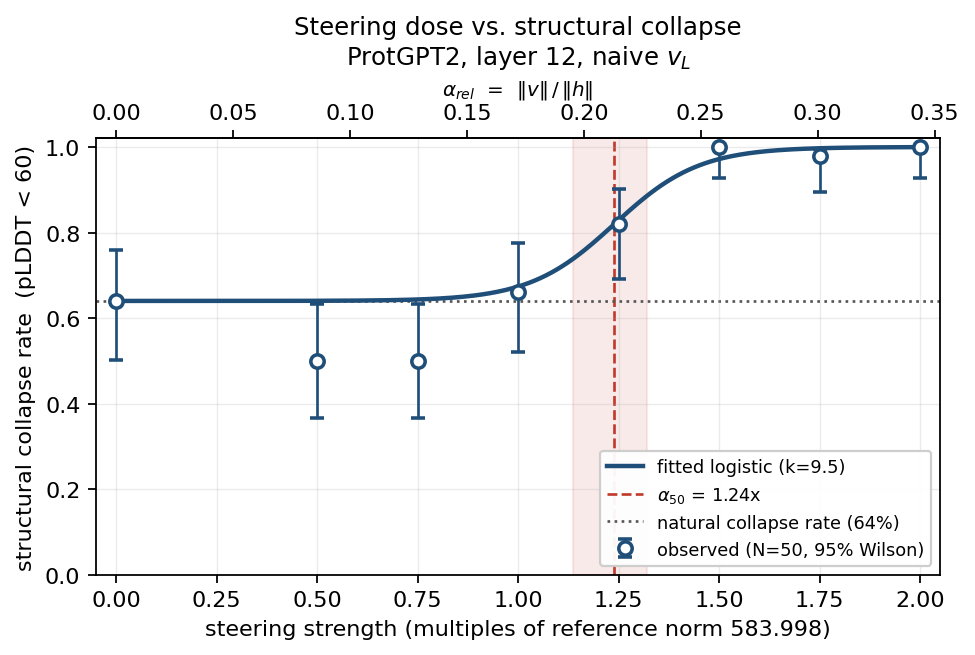

Saved dose_response_curve.png and .pdf -- both ready to drop into the paper.


In [7]:
# --- Figure. This is buildable directly into the paper as Figure 1 (see
#     notes/paper-outline.md, 'Figures needed' item 1). ---

fig, ax = plt.subplots(figsize=(6.2, 4.2), dpi=160)

x = dose_df["dose"].values
y = dose_df["rate"].values
yerr = np.vstack([y - dose_df["ci_lo"].values, dose_df["ci_hi"].values - y])

if not np.isnan(slope):
    xs = np.linspace(0, max(2.0, float(x.max())), 300)
    ax.plot(xs, model_p([slope, alpha50], xs, p0), lw=2, color="#1f4e79", zorder=2,
            label=f"fitted logistic (k={slope:.1f})")
    ax.axvline(alpha50, ls="--", lw=1.2, color="#c0392b", zorder=1,
               label=f"$\\alpha_{{50}}$ = {alpha50:.2f}x")
    if not np.isnan(boot_lo):
        ax.axvspan(boot_lo, boot_hi, color="#c0392b", alpha=0.10, zorder=0)

ax.errorbar(x, y, yerr=yerr, fmt="o", ms=6, capsize=3, lw=1.2,
            color="#1f4e79", mfc="white", mew=1.6, zorder=3, label="observed (N=50, 95% Wilson)")
ax.axhline(p0, ls=":", lw=1.2, color="#555555", zorder=1,
           label=f"natural collapse rate ({p0:.0%})")

ax.set_xlabel("steering strength (multiples of reference norm 583.998)")
ax.set_ylabel("structural collapse rate  (pLDDT < 60)")
ax.set_title("Steering dose vs. structural collapse\nProtGPT2, layer 12, naive $v_L$", fontsize=11)
ax.set_ylim(0, 1.02)
ax.set_xlim(-0.05, max(2.05, float(x.max()) + 0.05))
ax.grid(alpha=0.25, lw=0.6)
ax.legend(fontsize=8, loc="lower right", framealpha=0.95)

secax = ax.secondary_xaxis("top", functions=(lambda d: d * alpha_rel_per_dose,
                                             lambda a: a / alpha_rel_per_dose))
secax.set_xlabel(r"$\alpha_{rel}$  =  $\|v\| \, / \, \|h\|$", fontsize=9)

plt.tight_layout()
plt.savefig("dose_response_curve.png", dpi=300, bbox_inches="tight")
plt.savefig("dose_response_curve.pdf", bbox_inches="tight")
plt.show()
print("Saved dose_response_curve.png and .pdf -- both ready to drop into the paper.")


In [8]:
# --- Persist everything. ---
seq_rows = []
for dose, name in zip(DOSES, conditions):
    for i, r in enumerate(conditions[name]):
        seq_rows.append({
            "condition": name, "dose": dose, "alpha_rel": dose * alpha_rel_per_dose, "idx": i,
            "prompt": r["prompt"], "sequence": r["sequence"], "gen_only": r["gen_only"],
            "gen_length": len(r["gen_only"]),
            "usable_length": sum(1 for a in r["gen_only"] if a in VALID_AA),
            "entropy": r["entropy"], "plddt": r["plddt"], "ptm": r["ptm"],
            "collapse": r["collapse"],
        })
pd.DataFrame(seq_rows).to_csv("dose_response_sequences.csv", index=False)
dose_df.to_csv("dose_response_summary.csv", index=False)

fit_row = {
    "p0_floor": p0, "slope_k": slope, "alpha50_dose": alpha50,
    "alpha50_ci_lo": boot_lo, "alpha50_ci_hi": boot_hi,
    "alpha50_alpha_rel": alpha50 * alpha_rel_per_dose if not np.isnan(alpha50) else float("nan"),
    "resid_norm_h": resid_norm, "alpha_rel_per_dose": alpha_rel_per_dose,
    "reference_norm": REFERENCE_NORM, "layer": TARGET_LAYER,
    "largest_safe_dose": max(safe) if safe else float("nan"),
}
pd.DataFrame([fit_row]).to_csv("dose_response_fit.csv", index=False)

print("Saved:")
print("  dose_response_sequences.csv  (all 400 sequences with pLDDT/pTM/length)")
print("  dose_response_summary.csv    (per-dose collapse rates + Wilson CIs)")
print("  dose_response_fit.csv        (fitted threshold, CI, safe budget)")
print("  dose_response_curve.png/.pdf (Figure 1)")
print()
print("=" * 78)
print("WHAT TO DO WITH THIS")
print("=" * 78)
print("1. If the slope came out gradual, correct the 'cliff' language in")
print("   notes/context-and-decisions.md §1 -- it is currently stated as established.")
print("2. Add alpha_50 and the largest-safe-dose to notes/locked-results.md as a new section.")
print("3. The alpha_rel value of the threshold is the transferable number: combined with")
print("   34-ai4dd-residual-norm-audit.ipynb's per-model ‖h‖ table, it predicts the safe")
print("   absolute push for models this notebook never tested. That prediction is itself")
print("   testable and would make a strong closing paragraph.")


Saved:
  dose_response_sequences.csv  (all 400 sequences with pLDDT/pTM/length)
  dose_response_summary.csv    (per-dose collapse rates + Wilson CIs)
  dose_response_fit.csv        (fitted threshold, CI, safe budget)
  dose_response_curve.png/.pdf (Figure 1)

WHAT TO DO WITH THIS
1. If the slope came out gradual, correct the 'cliff' language in
   notes/context-and-decisions.md §1 -- it is currently stated as established.
2. Add alpha_50 and the largest-safe-dose to notes/locked-results.md as a new section.
3. The alpha_rel value of the threshold is the transferable number: combined with
   34-ai4dd-residual-norm-audit.ipynb's per-model ‖h‖ table, it predicts the safe
   absolute push for models this notebook never tested. That prediction is itself
   testable and would make a strong closing paragraph.
